In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/indian-pines/DSNet-main/flowchart.png
/kaggle/input/indian-pines/DSNet-main/LICENSE
/kaggle/input/indian-pines/DSNet-main/model.py
/kaggle/input/indian-pines/DSNet-main/README.md
/kaggle/input/indian-pines/DSNet-main/utils.py
/kaggle/input/indian-pines/DSNet-main/dataset.py
/kaggle/input/indian-pines/DSNet-main/demo.py
/kaggle/input/indian-pines/DSNet-main/data/IndianPine.mat
/kaggle/input/dsnetpaviau/PaviaU_conv2d_unmix_p7_99.68_epoch120.pkl
/kaggle/input/weights-pkl/Indian_conv2d_unmix_p7_91.6_epoch155.pkl
/kaggle/input/paviau/paviaU_gt.mat
/kaggle/input/paviau/paviaU.mat


In [2]:
import sys

In [3]:
sys.path.append('/kaggle/input/indian-pines/DSNet-main')

In [4]:
print(sys.path)

['/kaggle/working', '/kaggle/lib/kagglegym', '/kaggle/lib', '/usr/lib/python311.zip', '/usr/lib/python3.11', '/usr/lib/python3.11/lib-dynload', '', '/usr/local/lib/python3.11/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.11/dist-packages/IPython/extensions', '/usr/local/lib/python3.11/dist-packages/setuptools/_vendor', '/root/.ipython', '/kaggle/input/indian-pines/DSNet-main']


In [5]:
import os
import shutil

# Define the input directory and working directory paths
input_dir = '/kaggle/input/indian-pines/DSNet-main/data'
working_dir = '/kaggle/input/indian-pines/DSNet-main'


# List all directories in the input directory
input_folders = [f for f in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, f))]

# Copy each folder from input to working directory
for folder in input_folders:
    shutil.copytree(os.path.join(input_dir, folder), os.path.join(working_dir, folder))

In [6]:
#dataset 
import torch
import torch.utils.data as Data

from scipy.io import loadmat
import numpy as np

def prepare_dataset(args, samples_type='ratio'):
    # prepare data
    if args.dataset == 'Indian':
        data = loadmat('/kaggle/input/indian-pines/DSNet-main/data/IndianPine.mat')
        TR = data['TR']
        TE = data['TE']
        input = data['input'] #(145,145,200)
    elif args.dataset == 'Berlin':
        data = loadmat('./data/Berlin/data_HS_LR.mat')
        data_train = loadmat('./data/Berlin/TrainImage.mat')
        data_test = loadmat('./data/Berlin/TestImage.mat')
        TR = data_train['TrainImage']
        TE = data_test['TestImage']
        input = data['data_HS_LR'] #(1723,476,244)
    elif args.dataset == 'Augsburg':
        data = loadmat('./data/Augsburg/data_HS_LR.mat')
        data_train = loadmat('./data/Augsburg/TrainImage.mat')
        data_test = loadmat('./data/Augsburg/TestImage.mat')
        TR = data_train['TrainImage']
        TE = data_test['TestImage']
        input = data['data_HS_LR'] #(332,485,180)
    elif args.dataset == 'PaviaU':
        data = loadmat('/kaggle/input/paviau/paviaU.mat')
        labels = loadmat('/kaggle/input/paviau/paviaU_gt.mat')
        input = data['paviaU']  # Hyperspectral data cube (e.g., shape: 610,340,103)
        label = labels['paviaU_gt']  # Label map (2D array: 610x340)
        
        # You will need to split the label map into training and testing labels (TR and TE).
        # For now, create masks for TR and TE, e.g.:
        # TR = mask of training pixels (same size as label, with class labels where training samples are)
        # TE = mask of testing pixels (same size as label, with class labels where testing samples are)
        
        # Example: (you should adjust this according to your train/test splitting strategy)
        num_classes = np.max(label)
        
        # Simple example: split labeled pixels randomly into train/test (adjust as needed)
        train_ratio = 0.1  # 10% training samples
        TR = np.zeros_like(label)
        TE = np.zeros_like(label)
        
        for c in range(1, num_classes+1):
            indices = np.argwhere(label == c)
            np.random.shuffle(indices)
            n_train = int(len(indices) * train_ratio)
            train_idx = indices[:n_train]
            test_idx = indices[n_train:]
            
            for idx in train_idx:
                TR[idx[0], idx[1]] = c
            for idx in test_idx:
                TE[idx[0], idx[1]] = c


    else:
        raise ValueError("Unknown dataset")

    label = TR + TE
    # num_classes = np.max(TR)
    num_classes = np.max(label)#changed by balu
    # train data change to the ratio of train samples
    if samples_type == 'ratio':
        training_ratio = 1 # range from 0 to 1, e.g. training_ratio=0.5 means 50% training samples.
        print('Train data change to the ratio of train samples: {}'.format(training_ratio))
        train_idx, TR = split_train_data_clssnum(TR, num_classes, training_ratio)

    # normalize data by band norm
    input_normalize = np.zeros(input.shape)
    for i in range(input.shape[2]):
        input_max = np.max(input[:,:,i])
        input_min = np.min(input[:,:,i])
        input_normalize[:,:,i] = (input[:,:,i]-input_min)/(input_max-input_min)
    # data size
    height, width, band = input.shape
    print("height={0},width={1},band={2}".format(height, width, band))
    #-------------------------------------------------------------------------------
    # obtain train and test data
    total_pos_train, total_pos_test, total_pos_true, number_train, number_test, number_true = chooose_train_and_test_point(TR, TE, label, num_classes)
    mirror_image = mirror_hsi(height, width, band, input_normalize, patch=args.patches)
    x_train_band, x_test_band, x_true_band = train_and_test_data(mirror_image, band, total_pos_train, total_pos_test, patch=args.patches, true_point=total_pos_true)
    y_train, y_test, y_true = train_and_test_label(number_train, number_test, num_classes, number_true)
    #-------------------------------------------------------------------------------
    # # load data original code
    # x_train=torch.from_numpy(x_train_band.transpose(0,3,2,1)).type(torch.FloatTensor) #[695, 200, 7, 7]
    # y_train=torch.from_numpy(y_train).type(torch.LongTensor) #[695]
    # Label_train=Data.TensorDataset(x_train, y_train)
    # label_train_loader=Data.DataLoader(Label_train,batch_size=args.batch_size,shuffle=True)

    # x_test=torch.from_numpy(x_test_band.transpose(0,3,2,1)).type(torch.FloatTensor) # [9671, 200, 7, 7]
    # y_test=torch.from_numpy(y_test).type(torch.LongTensor) # [9671]
    # Label_test=Data.TensorDataset(x_test, y_test)
    # label_test_loader=Data.DataLoader(Label_test,batch_size=args.batch_size,shuffle=True)

    # x_true=torch.from_numpy(x_true_band.transpose(0,3,2,1)).type(torch.FloatTensor)
    # y_true=torch.from_numpy(y_true).type(torch.LongTensor)
    # Label_true=Data.TensorDataset(x_true, y_true)
    # label_true_loader=Data.DataLoader(Label_true,batch_size=args.batch_size,shuffle=False)
    
    x_train = torch.from_numpy(x_train_band.transpose(0, 3, 1, 2)).type(torch.FloatTensor)  # (N, C, H, W) updated by balu
    y_train = torch.from_numpy(y_train).type(torch.LongTensor)
    Label_train = Data.TensorDataset(x_train, y_train)
    label_train_loader = Data.DataLoader(Label_train, batch_size=args.batch_size, shuffle=True)
    
    x_test = torch.from_numpy(x_test_band.transpose(0, 3, 1, 2)).type(torch.FloatTensor)
    y_test = torch.from_numpy(y_test).type(torch.LongTensor)
    Label_test = Data.TensorDataset(x_test, y_test)
    label_test_loader = Data.DataLoader(Label_test, batch_size=args.batch_size, shuffle=True)
    
    x_true = torch.from_numpy(x_true_band.transpose(0, 3, 1, 2)).type(torch.FloatTensor)
    y_true = torch.from_numpy(y_true).type(torch.LongTensor)
    Label_true = Data.TensorDataset(x_true, y_true)
    label_true_loader = Data.DataLoader(Label_true, batch_size=args.batch_size, shuffle=False)
    return label_train_loader, label_test_loader, label_true_loader, band, height, width, num_classes, label, total_pos_true

# split dataset by training set ratio
def split_train_data_clssnum(gt, num_classes, train_num_ratio):
    train_idx = []

    TR = np.zeros_like(gt)
    for i in range(num_classes):
        idx = np.argwhere(gt == i + 1)
        samplesCount = len(idx)
        # print("Class", i, ":", samplesCount)
        sample_num = np.ceil(train_num_ratio * samplesCount).astype('int32')
        train_idx.append(idx[: sample_num])

        for j in range(sample_num):
            TR[idx[j,0], idx[j,1]] = i + 1

    train_idx = np.concatenate(train_idx, axis=0)
    return train_idx, TR

# 定位训练和测试样本
def chooose_train_and_test_point(train_data, test_data, true_data, num_classes):
    number_train = []
    pos_train = {}
    number_test = []
    pos_test = {}
    number_true = []
    pos_true = {}
    #-------------------------for train data------------------------------------
    for i in range(num_classes):
        each_class = []
        each_class = np.argwhere(train_data==(i+1))
        number_train.append(each_class.shape[0])
        pos_train[i] = each_class

    total_pos_train = pos_train[0]
    for i in range(1, num_classes):
        total_pos_train = np.r_[total_pos_train, pos_train[i]] #(695,2)
    total_pos_train = total_pos_train.astype(int)
    #--------------------------for test data------------------------------------
    for i in range(num_classes):
        each_class = []
        each_class = np.argwhere(test_data==(i+1))
        number_test.append(each_class.shape[0])
        pos_test[i] = each_class

    total_pos_test = pos_test[0]
    for i in range(1, num_classes):
        total_pos_test = np.r_[total_pos_test, pos_test[i]] #(9671,2)
    total_pos_test = total_pos_test.astype(int)
    #--------------------------for true data------------------------------------
    for i in range(num_classes+1):
        each_class = []
        each_class = np.argwhere(true_data==i)
        number_true.append(each_class.shape[0])
        pos_true[i] = each_class

    total_pos_true = pos_true[0]
    for i in range(1, num_classes+1):
        total_pos_true = np.r_[total_pos_true, pos_true[i]]
    total_pos_true = total_pos_true.astype(int)

    return total_pos_train, total_pos_test, total_pos_true, number_train, number_test, number_true

# 边界拓展：镜像
def mirror_hsi(height, width, band, input_normalize, patch=5):
    padding=patch//2
    mirror_hsi=np.zeros((height+2*padding,width+2*padding,band),dtype=float)
    #中心区域
    mirror_hsi[padding:(padding+height),padding:(padding+width),:]=input_normalize
    #左边镜像
    for i in range(padding):
        mirror_hsi[padding:(height+padding),i,:]=input_normalize[:,padding-i-1,:]
    #右边镜像
    for i in range(padding):
        mirror_hsi[padding:(height+padding),width+padding+i,:]=input_normalize[:,width-1-i,:]
    #上边镜像
    for i in range(padding):
        mirror_hsi[i,:,:]=mirror_hsi[padding*2-i-1,:,:]
    #下边镜像
    for i in range(padding):
        mirror_hsi[height+padding+i,:,:]=mirror_hsi[height+padding-1-i,:,:]

    print("**************************************************")
    print("patch is : {}".format(patch))
    print("mirror_image shape : [{0},{1},{2}]".format(mirror_hsi.shape[0],mirror_hsi.shape[1],mirror_hsi.shape[2]))
    print("**************************************************")
    return mirror_hsi

# 获取patch的图像数据
def gain_neighborhood_pixel(mirror_image, point, i, patch=5):
    x = point[i,0]
    y = point[i,1]
    temp_image = mirror_image[x:(x+patch),y:(y+patch),:]
    return temp_image

# 汇总训练数据和测试数据
def train_and_test_data(mirror_image, band, train_point, test_point, patch=5, true_point=None):
    x_train = np.zeros((train_point.shape[0], patch, patch, band), dtype=float)
    x_test = np.zeros((test_point.shape[0], patch, patch, band), dtype=float)

    for i in range(train_point.shape[0]):
        x_train[i,:,:,:] = gain_neighborhood_pixel(mirror_image, train_point, i, patch)
    for j in range(test_point.shape[0]):
        x_test[j,:,:,:] = gain_neighborhood_pixel(mirror_image, test_point, j, patch)

    print("x_train shape = {}, type = {}".format(x_train.shape,x_train.dtype))
    print("x_test  shape = {}, type = {}".format(x_test.shape,x_test.dtype))
    # if true_point.all() != None:
    if true_point is not None and true_point.size > 0:
        x_true = np.zeros((true_point.shape[0], patch, patch, band), dtype=float)
        for k in range(true_point.shape[0]):
            x_true[k,:,:,:] = gain_neighborhood_pixel(mirror_image, true_point, k, patch)
        print("x_true  shape = {}, type = {}".format(x_true.shape,x_test.dtype))
        print("**************************************************")
        return x_train, x_test, x_true
    else:
        print("**************************************************")
        return x_train, x_test

# 标签y_train, y_test
def train_and_test_label(number_train, number_test, num_classes, number_true=None):
    y_train = []
    y_test = []
    for i in range(num_classes):
        for j in range(number_train[i]):
            y_train.append(i)
        for k in range(number_test[i]):
            y_test.append(i)
    y_train = np.array(y_train)
    y_test = np.array(y_test)
    print("y_train: shape = {} ,type = {}".format(y_train.shape,y_train.dtype))
    print("y_test: shape = {} ,type = {}".format(y_test.shape,y_test.dtype))

    if number_true != None:
        y_true = []
        for i in range(num_classes+1):
            for j in range(number_true[i]):
                y_true.append(i)
        y_true = np.array(y_true)
        print("y_true: shape = {} ,type = {}".format(y_true.shape,y_true.dtype))
        print("**************************************************")
        return y_train, y_test, y_true
    else:
        print("**************************************************")
        return y_train, y_test


In [7]:
#model
import torch
import torch.nn as nn
from torch.nn import init

import numpy as np
import math

class Conv_Classifier(nn.Module):
    @staticmethod
    def weight_init(m):
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            nn.init.kaiming_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def __init__(self, input_channels, num_classes, patch_size=7, n_planes=64):
        super(Conv_Classifier, self).__init__()
        self.input_channels = input_channels
        self.n_planes = n_planes
        self.patch_size = patch_size

        self.conv1 = nn.Conv2d(input_channels, n_planes, (3, 3), stride=(1, 1))
        self.conv2 = nn.Conv2d(n_planes, 100, (3, 3), stride=(1, 1))
        self.relu = nn.ReLU()

        self.feature_size = self._get_final_flattened_size()
        self.fc1 = nn.Linear(self.feature_size, 100)
        self.fc2 = nn.Linear(100, num_classes)
        self.apply(self.weight_init)

    def _get_final_flattened_size(self):
        with torch.no_grad():
            x = torch.zeros((1, self.input_channels, self.patch_size, self.patch_size))
            x = self.relu(self.conv1(x))
            x = self.relu(self.conv2(x))
            _, c, w, h = x.size()
            return c * w * h

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.view(-1, self.feature_size)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class DSNet(nn.Module):
    """
    dual-branch subpixel-guided network for hyperspectral image classification
    """
    def __init__(self, band, num_classes, patch_size, basic_cls_name):
        super(DSNet, self).__init__()
        self.num_classes = num_classes
        self.patch_size = patch_size
        self.basic_cls_name = basic_cls_name
        # unmixing module
        self.unmix_encoder = nn.Sequential(
            nn.Conv2d(band, band//2, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(band//2),
            nn.ReLU(),
            nn.Conv2d(band//2, band//4, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm2d(band//4),
            nn.ReLU(),
            nn.Conv2d(band//4, num_classes, kernel_size=1, stride=1, padding=0)
        )
        self.unmix_decoder = nn.Sequential(
            nn.Conv2d(num_classes, band*2, kernel_size=1, stride=1, bias=False),
            nn.ReLU()
        )
        self.unmix_decoder_nonlinear = nn.Sequential(
            nn.Conv2d(band*2, band, kernel_size=1, stride=1, bias=True),
            nn.Sigmoid(),
            nn.Conv2d(band, band, kernel_size=1, stride=1, bias=True),
            nn.Sigmoid()
        )

        # basic classification backbone module
        if 'conv2d' in basic_cls_name:
            self.cls = Conv_Classifier(band, num_classes, patch_size, 64)
        else:
            raise KeyError("{} model is unknown.".format(basic_cls_name))
        # fusion module
        self.conv = nn.Sequential(
            nn.Conv2d(num_classes, num_classes, kernel_size=3, stride=2, padding=0),
            nn.BatchNorm2d(num_classes),
            nn.ReLU(),
        )
        self.feature_size = self._get_final_flattened_size()
        self.fc = nn.Linear(self.feature_size, num_classes)

    def _get_final_flattened_size(self):
        with torch.no_grad():
            x = torch.zeros((1, self.num_classes, self.patch_size, self.patch_size))
            x = self.conv(x)
            _, c, w, h = x.size()
            return c * w * h + self.num_classes

    def forward(self, x):
        abu = self.unmix_encoder(x)
        re_unmix = self.unmix_decoder(abu)
        re_unmix_nonlinear = self.unmix_decoder_nonlinear(re_unmix)
        feature_cls = self.cls(x) # cls token
        # abu sum-to-one and nonnegative constraint
        abu = abu.abs()
        abu = abu / abu.sum(1).unsqueeze(1)
        # reshape abu
        feature_abu = self.conv(abu)
        abu_v = feature_abu.reshape(x.shape[0], -1)
        # fuse abu features and cls token
        feature_fuse = torch.cat([abu_v, feature_cls], dim=1)
        output_cls = self.fc(feature_fuse)
        return re_unmix_nonlinear, re_unmix, output_cls

Train data change to the ratio of train samples: 1
height=610,width=340,band=103
**************************************************
patch is : 7
mirror_image shape : [616,346,103]
**************************************************
x_train shape = (4273, 7, 7, 103), type = float64
x_test  shape = (38503, 7, 7, 103), type = float64
x_true  shape = (207400, 7, 7, 103), type = float64
**************************************************
y_train: shape = (4273,) ,type = int64
y_test: shape = (38503,) ,type = int64
y_true: shape = (207400,) ,type = int64
**************************************************
Model Name: conv2d_unmix
****************start_test*******************

*********************loading_weights**********************

****************test_epoch***********************

Overall Accuracy (OA): 0.9971
Average Accuracy (AA): 0.9949
Kappa Coefficient: 0.9961


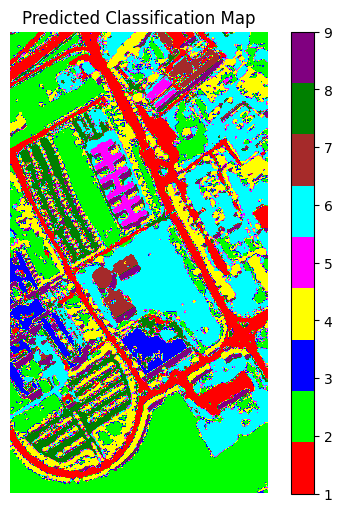

Final result:
OA: 0.0000 | AA: 0.0000 | Kappa: 0.0000
0.0
**************************************************
Best Epoch: 000 | Best OA: 0.0000 | Best AA: 0.0000 | Best Kappa: 0.0000
0.0
**************************************************
Parameter:
fix_random: True
gpu_id: 1
seed: 0
dataset: PaviaU
flag_test: test
model_name: conv2d_unmix
batch_size: 64
test_freq: 5
patches: 7
epoches: 500
learning_rate: 0.001
gamma: 0.9
weight_decay: 0


In [13]:
#demo

import torch
import argparse
import torch.nn as nn
import torch.utils.data as Data
import torch.backends.cudnn as cudnn
from scipy.io import savemat
from torch import optim
from model import DSNet
from utils import AvgrageMeter, accuracy, output_metric, NonZeroClipper, print_args
# from dataset import prepare_dataset
import numpy as np
import time
import os
import sys
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt



parser = argparse.ArgumentParser("HSI")



parser.add_argument('--fix_random', action='store_true', default=True, help='fix randomness')
parser.add_argument('--gpu_id', default='1', help='gpu id')
parser.add_argument('--seed', type=int, default=0, help='number of seed')
parser.add_argument('--dataset', choices=['Indian', 'Berlin', 'Augsburg'], default='PaviaU', help='dataset to use')#Indian
parser.add_argument('--flag_test', choices=['test', 'train'], default='test', help='testing mark')#changed by balu
parser.add_argument('--model_name', choices=['conv2d_unmix'], default='conv2d_unmix', help='DSNet')
parser.add_argument('--batch_size', type=int, default=64, help='number of batch size')
parser.add_argument('--test_freq', type=int, default=5, help='number of evaluation') #5
parser.add_argument('--patches', type=int, default=7, help='number of patches')
parser.add_argument('--epoches', type=int, default=500, help='epoch number')
parser.add_argument('--learning_rate', type=float, default=1e-3, help='learning rate')
parser.add_argument('--gamma', type=float, default=0.9, help='gamma')
parser.add_argument('--weight_decay', type=float, default=0, help='weight_decay')
args = parser.parse_args(args=[]) if '__file__' not in globals() else parser.parse_args()


def train_epoch(model, train_loader, criterion, optimizer):
    objs = AvgrageMeter()
    top1 = AvgrageMeter()
    tar = np.array([])
    pre = np.array([])
    for batch_idx, (batch_data, batch_target) in enumerate(train_loader):
        batch_data = batch_data.cuda()
        batch_target = batch_target.cuda()

        optimizer.zero_grad()
        if 'unmix' in args.model_name:
            re_unmix_nonlinear, re_unmix, batch_pred = model(batch_data)

            band = re_unmix.shape[1]//2  # 2 represents the number of layer
            output_linear = re_unmix[:,0:band] + re_unmix[:,band:band*2]
            re_unmix = re_unmix_nonlinear + output_linear

            sad_loss = torch.mean(torch.acos(torch.sum(batch_data * re_unmix, dim=1)/
                        (torch.norm(re_unmix, dim=1, p=2) * torch.norm(batch_data, dim=1, p=2))))
            loss = criterion(batch_pred, batch_target) + sad_loss
        else:
            batch_pred = model(batch_data)
            loss = criterion(batch_pred, batch_target)
        loss.backward()
        optimizer.step()

        prec1, t, p = accuracy(batch_pred, batch_target, topk=(1,))
        n = batch_data.shape[0]
        objs.update(loss.data, n)
        top1.update(prec1[0].data, n)
        tar = np.append(tar, t.data.cpu().numpy())
        pre = np.append(pre, p.data.cpu().numpy())
    # print(batch_idx,"batch_idx")
    # print(batch_data.shape,'batch_data')
    # print(batch_target.shape,'batch_target')
    # print(len(batch_data),'batch_data length')
    # print(len(batch_target),'batch_target length')
    
    return top1.avg, objs.avg, tar, pre

def valid_epoch(model, valid_loader, criterion, optimizer):
    objs = AvgrageMeter()
    top1 = AvgrageMeter()
    tar = np.array([])
    pre = np.array([])
    for batch_idx, (batch_data, batch_target) in enumerate(valid_loader):
        batch_data = batch_data.cuda()
        batch_target = batch_target.cuda()

        if 'unmix' in args.model_name:
            re_unmix_nonlinear, re_unmix, batch_pred = model(batch_data)

            band = re_unmix.shape[1]//2
            output_linear = re_unmix[:,0:band] + re_unmix[:,band:band*2]
            re_unmix = re_unmix_nonlinear + output_linear

            sad_loss = torch.mean(torch.acos(torch.sum(batch_data * re_unmix, dim=1)/
                        (torch.norm(re_unmix, dim=1, p=2) * torch.norm(batch_data, dim=1, p=2))))
            loss = criterion(batch_pred, batch_target) + sad_loss
        else:
            batch_pred = model(batch_data)
            loss = criterion(batch_pred, batch_target)

        prec1, t, p = accuracy(batch_pred, batch_target, topk=(1,))
        n = batch_data.shape[0]
        objs.update(loss.data, n)
        top1.update(prec1[0].data, n)
        tar = np.append(tar, t.data.cpu().numpy())
        pre = np.append(pre, p.data.cpu().numpy())
    return tar, pre

def test_epoch(model, test_loader):
    pre = np.array([])
    for batch_idx, (batch_data, batch_target) in enumerate(test_loader):
        batch_data = batch_data.cuda()
        batch_target = batch_target.cuda()

        if 'unmix' in args.model_name:
            re_unmix_nonlinear, re_unmix, batch_pred = model(batch_data)
        else:
            batch_pred = model(batch_data)

        _, pred = batch_pred.topk(1, 1, True, True)
        pp = pred.squeeze()
        pre = np.append(pre, pp.data.cpu().numpy())

    return pre

def main():
    #added
    OA2, AA_mean2, Kappa2, AA2 = 0.0, 0.0, 0.0,0.0
    best_epoch, best_OA, best_AA, best_Kappa, best_each_AA = 0, 0.0, 0.0, 0.0, 0.0
    
    os.environ["CUDA_VISIBLE_DEVICES"] = str(args.gpu_id)

    if args.fix_random:
        np.random.seed(args.seed)
        torch.manual_seed(args.seed)
        torch.cuda.manual_seed(args.seed)
        cudnn.deterministic = True
        cudnn.benchmark = False
    else:
        cudnn.benchmark = True

    ## prepare dataset
    label_train_loader, label_test_loader, label_true_loader, band, height, width, num_classes, label, total_pos_true = prepare_dataset(args)
    # create model
    if args.model_name == 'conv2d_unmix':
        model = DSNet(band, num_classes, args.patches, args.model_name)
    else:
        raise KeyError("{} model is unknown.".format(args.model_name))
    model = model.cuda()
    print("Model Name: {}".format(args.model_name))

    # criterion
    criterion = nn.CrossEntropyLoss().cuda()
    # Set the optimizer
    if 'unmix' in args.model_name:
        params = map(id, model.unmix_decoder.parameters())
        ignored_params = list(set(params))
        base_params = filter(lambda p: id(p) not in ignored_params, model.parameters())
        optimizer = torch.optim.Adam([{'params': base_params},{'params': model.unmix_decoder.parameters(), 'lr': 3e-4}],
                                    lr = args.learning_rate, weight_decay = args.weight_decay)
    else:
        optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate, weight_decay=args.weight_decay)

    apply_nonegative = NonZeroClipper()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args.epoches//10, gamma=args.gamma)
    #-------------------------------------------------------------------------------
    # if args.flag_test == 'test':
    #     print('****************start_test*******************\n')
    #     model.eval()
        
    #     model.load_state_dict(torch.load('/kaggle/input/indian-pine-weights/Indian_conv2d_unmix_p7_91.6_epoch155.pkl'))
    #     print('*********************loading_weights**********************\n')
        
    #     pre_u = test_epoch(model, label_true_loader)
    #     print('****************test_epoch***********************\n')

    #     prediction_matrix = np.zeros((height, width), dtype=float)
        
        
    #     for i in range(total_pos_true.shape[0]):
    #         prediction_matrix[total_pos_true[i,0], total_pos_true[i,1]] = pre_u[i] + 1
    #     savemat('matrix.mat',{'P':prediction_matrix, 'label':label})

    #     #added code to get the oa aa and kappa values from the saved matrix
        
    #     data = loadmat('/kaggle/working/matrix.mat')
    #     prediction_matrix = data['P']
    #     ground_truth = data['label']

    #     # Flatten to match label format
    #     y_true = ground_truth.flatten()
    #     y_pred = prediction_matrix.flatten()

    #     # Remove zero-label pixels (background) if necessary
    #     valid_idx = y_true > 0  # Ignore zero labels
    #     y_true = y_true[valid_idx]
    #     y_pred = y_pred[valid_idx]

    #     # Compute metrics
    #     OA = accuracy_score(y_true, y_pred)
    #     Kappa = cohen_kappa_score(y_true, y_pred)
    #     report = classification_report(y_true, y_pred, output_dict=True)

    #     # Compute Average Accuracy (AA)
    #     AA = np.mean([report[str(cls)]['recall'] for cls in np.unique(y_true)])

    #     print(f"Overall Accuracy (OA): {OA:.4f}")
    #     print(f"Average Accuracy (AA): {AA:.4f}")
    #     print(f"Kappa Coefficient: {Kappa:.4f}")
    #___________________________________________________________________________________
    # if args.flag_test == 'test':
    #     print('****************start_test*******************\n')
    #     model.eval()
    #     #changed
    #     # weight_path = '/kaggle/input/weights-pkl/Indian_conv2d_unmix_p7_91.6_epoch155.pkl'
    #      weight_path = '/kaggle/input/dsnetpaviau/PaviaU_conv2d_unmix_p7_99.68_epoch120.pkl'
        
    #     model.load_state_dict(torch.load(weight_path))
    #     #changed
    #     #model.load_state_dict(torch.load('/kaggle/input/weights-pkl/Indian_conv2d_unmix_p7_91.6_epoch155.pkl'))
    #     print('*********************loading_weights**********************\n')
    
    #     pre_u = test_epoch(model, label_true_loader)
    #     print('****************test_epoch***********************\n')

    #     prediction_matrix = np.zeros((height, width), dtype=float)
    
    #     for i in range(total_pos_true.shape[0]):
    #         prediction_matrix[total_pos_true[i,0], total_pos_true[i,1]] = pre_u[i] + 1
    #     savemat('matrix.mat',{'P':prediction_matrix, 'label':label})

    #     # Load saved matrix for evaluation
    #     data = loadmat('/kaggle/working/matrix.mat')
    #     prediction_matrix = data['P']
    #     ground_truth = data['label']

    #     # Flatten to match label format
    #     y_true = ground_truth.flatten()
    #     y_pred = prediction_matrix.flatten()

    #     # Remove zero-label pixels (background) if necessary
    #     valid_idx = y_true > 0  # Ignore zero labels
    #     y_true = y_true[valid_idx]
    #     y_pred = y_pred[valid_idx]

    #     # Compute metrics
    #     OA2 = accuracy_score(y_true, y_pred)
    #     Kappa2 = cohen_kappa_score(y_true, y_pred)
    #     report = classification_report(y_true, y_pred, output_dict=True)

    #     # Compute Average Accuracy (AA)
    #     AA2 = np.mean([report[str(cls)]['recall'] for cls in np.unique(y_true)])
    #     AA_mean2 = AA2  # To ensure consistency with training variables

    #     print(f"Overall Accuracy (OA): {OA2:.4f}")
    #     print(f"Average Accuracy (AA): {AA_mean2:.4f}")
    #     print(f"Kappa Coefficient: {Kappa2:.4f}")
    #     #changed
   
    #     model.eval()

    # # Load weights
    # # For PaviaU dataset
    # # model.load_state_dict(torch.load('/kaggle/input/dsnet-pavia-train/kaggle/working/results/Indian_conv2d_unmix_p7_99.74_epoch110.pkl'))

    # # For Indian Pines dataset
    #     model.load_state_dict(torch.load('/kaggle/input/weights-pkl/Indian_conv2d_unmix_p7_91.6_epoch155.pkl'))

    # # Run test
    #     pre_u = test_epoch(model, label_true_loader)

    # # Generate prediction matrix
    #     prediction_matrix = np.zeros((height, width), dtype=int)
    #     for i in range(total_pos_true.shape[0]):
    #          prediction_matrix[total_pos_true[i, 0], total_pos_true[i, 1]] = int(pre_u[i]) + 1  # Add 1 if your labels start from 1

    # # Save matrix
    #     savemat('matrix.mat', {'P': prediction_matrix, 'label': label})

    # # Define colormap for Indian Pines
    #     dsnet_cmap = ListedColormap([
    #        (0/255, 133/255, 0/255),         # 1: Corn Notill
    #        (169/255, 209/255, 102/255),     # 2: Corn Mintill
    #        (45/255, 124/255, 50/255),       # 3: Corn
    #        (103/255, 173/255, 95/255),      # 4: Grass Pasture
    #        (158/255, 95/255, 49/255),       # 5: Grass Trees
    #        (129/255, 208/255, 215/255),     # 6: Hay Windrowed
    #        (255/255, 255/255, 255/255),     # 7: Soybean Notill
    #        (213/255, 194/255, 213/255),     # 8: Soybean Mintill
    #        (237/255, 28/255, 36/255),       # 9: Soybean Clean
    #        (121/255, 31/255, 31/255),       # 10: Wheat
    #        (60/255, 90/255, 148/255),       # 11: Woods
    #        (255/255, 255/255, 102/255),     # 12: Buildings Grass Trees Drives
    #        (232/255, 158/255, 52/255),      # 13: Stone Steel Towers
    #        (81/255, 56/255, 145/255),       # 14: Alfalfa
    #        (242/255, 101/255, 66/255),      # 15: Grass Pasture Mowed
    #        (142/255, 81/255, 123/255),      # 16: Oats
    #      ])

    # # Display and save classification map
    #     plt.figure(figsize=(6, 6))
    #     plt.imshow(prediction_matrix, cmap=dsnet_cmap)
    #     plt.title('Predicted Classification Map')
    #     plt.axis('off')
    #     plt.savefig('/kaggle/working/classification_map.png', bbox_inches='tight')
    #     plt.show()

    

    if args.flag_test == 'test':
        print('****************start_test*******************\n')
        model.eval()
    
        weight_path = '/kaggle/input/dsnetpaviau/PaviaU_conv2d_unmix_p7_99.68_epoch120.pkl'
        model.load_state_dict(torch.load(weight_path))
        print('*********************loading_weights**********************\n')
    
        pre_u = test_epoch(model, label_true_loader)
        print('****************test_epoch***********************\n')
    
        prediction_matrix = np.zeros((height, width), dtype=int)
        for i in range(total_pos_true.shape[0]):
            prediction_matrix[total_pos_true[i, 0], total_pos_true[i, 1]] = int(pre_u[i]) + 1  # adjust if labels start at 1
    
        savemat('matrix.mat', {'P': prediction_matrix, 'label': label})
    
        y_true = label.flatten()
        y_pred = prediction_matrix.flatten()
    
        valid_idx = y_true > 0  # ignore background
        y_true = y_true[valid_idx]
        y_pred = y_pred[valid_idx]
    
        OA = accuracy_score(y_true, y_pred)
        Kappa = cohen_kappa_score(y_true, y_pred)
        report = classification_report(y_true, y_pred, output_dict=True)
        AA = np.mean([report[str(cls)]['recall'] for cls in np.unique(y_true)])
    
        print(f"Overall Accuracy (OA): {OA:.4f}")
        print(f"Average Accuracy (AA): {AA:.4f}")
        print(f"Kappa Coefficient: {Kappa:.4f}")

        # # Define colormap for Indian Pines
        custom_colors = [
            '#FF0000',  # White for background (class 0)
            '#00FF00',  # Blue
            '#0000FF',  # Green
            '#FFFF00',  # Red
            '#FF00FF',  # Navy Blue
            '#00FFFF',  # Dark Green
            '#A52A2A',  # Magenta
            '#008000',  # Yellow
            '#800080'  # Cyan
            # '#8B4513'  # Brown
            # '#ADFF2F',  # Green-Yellow
            # '#808080',  # Gray
            # '#FFA500',  # Orange
            # '#B19CD9',  # Lavender
            # '#87CEEB',  # Sky Blue
            # '#800000',  # Maroon
            # '#00008B'   # Dark Blue
        ]  # White for background (class 0)

        dsnet_cmap = ListedColormap(custom_colors)
        # dsnet_cmap = ListedColormap([
        #    (0/255, 133/255, 0/255),         # 1: Corn Notill
        #    (169/255, 209/255, 102/255),     # 2: Corn Mintill
        #    (45/255, 124/255, 50/255),       # 3: Corn
        #    (103/255, 173/255, 95/255),      # 4: Grass Pasture
        #    (158/255, 95/255, 49/255),       # 5: Grass Trees
        #    (129/255, 208/255, 215/255),     # 6: Hay Windrowed
        #    (255/255, 255/255, 255/255),     # 7: Soybean Notill
        #    (213/255, 194/255, 213/255),     # 8: Soybean Mintill
        #    (237/255, 28/255, 36/255),       # 9: Soybean Clean
        #    (121/255, 31/255, 31/255),       # 10: Wheat
        #    (60/255, 90/255, 148/255),       # 11: Woods
        #    (255/255, 255/255, 102/255),     # 12: Buildings Grass Trees Drives
        #    (232/255, 158/255, 52/255),      # 13: Stone Steel Towers
        #    (81/255, 56/255, 145/255),       # 14: Alfalfa
        #    (242/255, 101/255, 66/255),      # 15: Grass Pasture Mowed
        #    (142/255, 81/255, 123/255),      # 16: Oats
        #  ])
        # Colormap for Indian Pines (or adjust to your dataset)
        # dsnet_cmap = ListedColormap([...])  # keep your cmap here
    
        plt.figure(figsize=(6, 6))
        # plt.imshow(prediction_matrix, cmap=dsnet_cmap)#original
        plt.imshow(prediction_matrix, cmap=dsnet_cmap)  # or any other valid colormap

        plt.title('Predicted Classification Map')
        plt.axis('off')
        # plt.savefig('/kaggle/working/classification_map.png', bbox_inches='tight')
        plt.colorbar()
        plt.show()

    else:
        print("start training")
        tic = time.time()
        min_val_obj, best_OA = 0.5, 0
        for epoch in range(args.epoches):
            optimizer.step()  # ✅ Correct order

            scheduler.step()

            # train model
            model.train()
            train_acc, train_obj, tar_t, pre_t = train_epoch(model, label_train_loader, criterion, optimizer)
            OA1, AA_mean1, Kappa1, AA1 = output_metric(tar_t, pre_t)
            print("Epoch: {:03d} train_loss: {:.4f} train_acc: {:.4f}"
                            .format(epoch+1, train_obj, train_acc))

            if 'unmix' in args.model_name: # regularize unmix decoder
                model.unmix_decoder.apply(apply_nonegative)

            if (epoch % args.test_freq == 0) | (epoch == args.epoches - 1):
                model.eval()
                tar_v, pre_v = valid_epoch(model, label_test_loader, criterion, optimizer)
                OA2, AA_mean2, Kappa2, AA2 = output_metric(tar_v, pre_v)
                print("OA: {:.4f} AA: {:.4f} Kappa: {:.4f}"
                            .format(OA2, AA_mean2, Kappa2))
                print("*************************")

                # if OA2 > min_val_obj and epoch > 10:
                #     model_save_path = os.path.join('./results/', args.dataset+'_'+args.model_name+'_p'+str(args.patches)+
                #                                     '_'+str(round(OA2*100, 2))+'_epoch'+str(epoch)+'.pkl')
                #     torch.save(model.state_dict(), model_save_path)

                #     min_val_obj = OA2
                #     best_epoch = epoch
                #     best_OA = OA2
                #     best_AA = AA_mean2
                #     best_Kappa = Kappa2
                #     best_each_AA = AA2
                if OA2 > min_val_obj and epoch > 10:
                    model_save_path = os.path.join('./results/', args.dataset+'_'+args.model_name+'_p'+str(args.patches)+
                                   '_'+str(round(OA2*100, 2))+'_epoch'+str(epoch)+'.pkl')

                    # Ensure the results directory exists before saving the model
                    os.makedirs("./results", exist_ok=True)

                    # Save the model
                    torch.save(model.state_dict(), model_save_path)

                    min_val_obj = OA2
                    best_epoch = epoch
                    best_OA = OA2
                    best_AA = AA_mean2
                    best_Kappa = Kappa2
                    best_each_AA = AA2

        toc = time.time()
        print("Running Time: {:.2f}".format(toc-tic))
        print("**************************************************")
        if best_OA == 0:
            model_save_path = os.path.join('./results/', args.dataset+'_'+args.model_name+'_p'+str(args.patches)+
                                            '_'+str(round(OA2*100, 2))+'_epoch'+str(epoch)+'.pkl')
            torch.save(model.state_dict(), model_save_path)

    print("Final result:")
    print("OA: {:.4f} | AA: {:.4f} | Kappa: {:.4f}".format(OA2, AA_mean2, Kappa2))
    print(AA2)
    print("**************************************************")
    print("Best Epoch: {:03d} | Best OA: {:.4f} | Best AA: {:.4f} | Best Kappa: {:.4f}".format(best_epoch, best_OA, best_AA, best_Kappa))
    print(best_each_AA)
    print("**************************************************")
    print("Parameter:")
    print_args(vars(args))

if __name__ == '__main__':
    main()


In [9]:
from scipy.io import loadmat

data = loadmat('/kaggle/input/paviau/paviaU.mat')
print(data.keys())
gt_data = loadmat('/kaggle/input/paviau/paviaU_gt.mat')
print(gt_data.keys())


dict_keys(['__header__', '__version__', '__globals__', 'paviaU'])
dict_keys(['__header__', '__version__', '__globals__', 'paviaU_gt'])


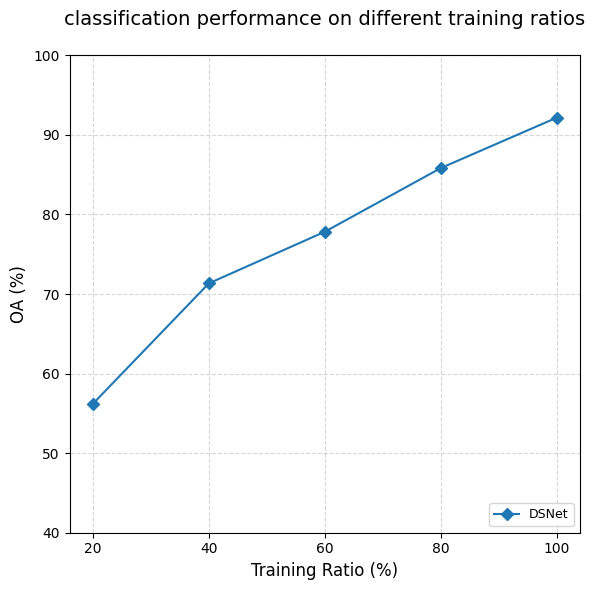

In [10]:
import matplotlib.pyplot as plt

# X-axis: Training Ratios
x = [20, 40, 60, 80, 100]

# OA values for each model (example dummy data — replace with your real values)

oa_dsnet     = [56.20, 71.34, 77.83, 85.83, 92.17]

# Set up plot
plt.figure(figsize=(6, 6))

plt.plot(x, oa_dsnet,     'D-',  label='DSNet')

# Axis and styling
plt.xlabel('Training Ratio (%)', fontsize=12)
plt.ylabel('OA (%)', fontsize=12)
plt.xticks([20, 40, 60, 80, 100])
plt.yticks(range(40, 101, 10))
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('classification performance on different training ratios\n', loc='center', fontsize=14)

# Legend
plt.legend(fontsize=9, loc='lower right', frameon=True)

# Layout
plt.tight_layout()
plt.show()